In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

In [67]:
df = pd.read_csv("som3aa.csv")

print(df.shape)
df.head()

(36178, 16)


,Glucose,HbA1c,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,Systolic Blood Pressure,Diastolic Blood Pressure,LDL Cholesterol,HDL Cholesterol,Triglycerides,Target
0,113.92,4.73,14.03,245.9,7.47,4.69,39.1,88.85,27.94,32.9,106.06,66.84,126.53,51.78,79.99,1
1,101.87,6.15,7.66,245.9,7.47,4.69,39.1,72.74,27.94,32.9,112.70,60.76,109.82,53.31,107.34,1
2,111.28,5.72,14.33,245.9,7.47,4.69,39.1,92.24,27.94,32.9,122.04,63.16,129.63,53.55,134.05,1
3,77.30,6.17,12.60,245.9,7.47,4.69,39.1,90.68,27.94,32.9,94.62,69.44,71.29,59.93,125.57,1
4,96.00,5.74,12.14,245.9,7.47,4.69,39.1,90.65,27.94,32.9,104.49,62.11,108.89,53.35,83.61,1


In [68]:
# إزالة outliers الغريبة في WBC
df = df[df['White Blood Cells'] < 50]

# تنظيف بسيط
df = df[
    (df['Glucose'] > 50) &
    (df['Hemoglobin'] > 5) &
    (df['White Blood Cells'] > 1)
].reset_index(drop=True)

In [69]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [72]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SVM": SVC(probability=True)
}

In [73]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1"
])

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.976454,0.977755,0.867265,0.919202
1,Random Forest,0.982548,0.997986,0.888789,0.940228
2,SVM,0.978532,0.992813,0.867265,0.925802


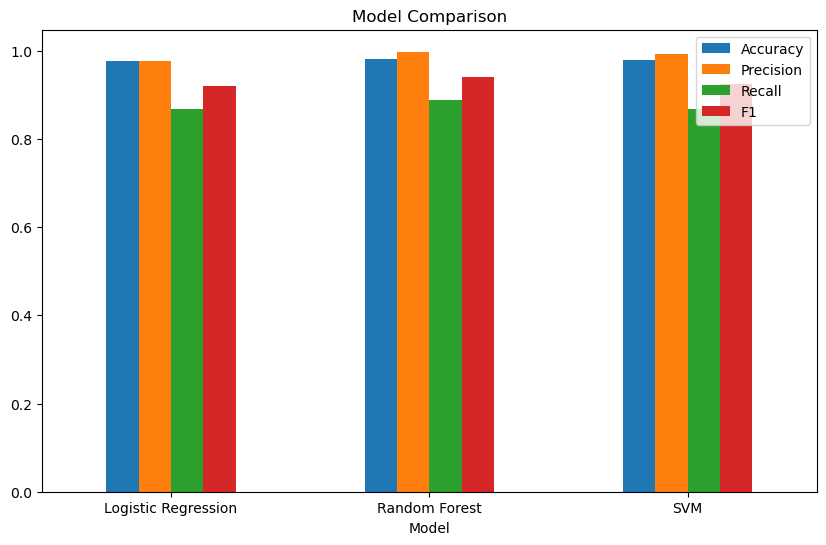

In [74]:
results_df.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

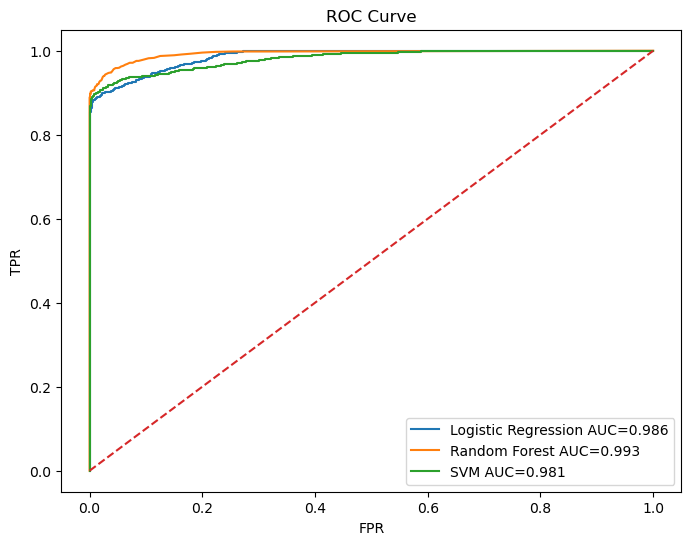

In [75]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} AUC={auc_score:.3f}")

plt.plot([0,1],[0,1],"--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

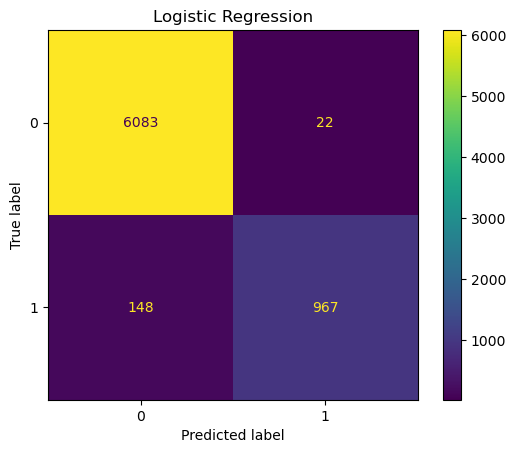

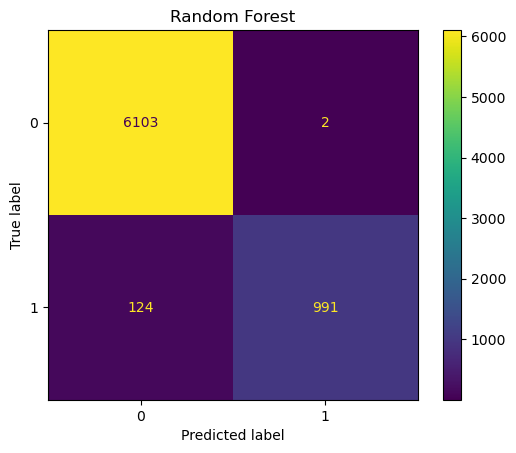

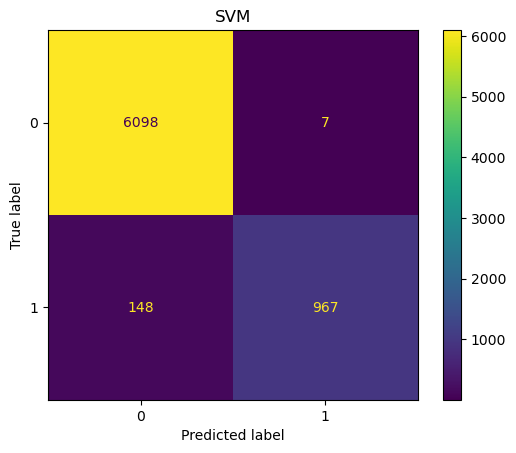

In [76]:
for name, model in models.items():
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)

    disp.plot()
    plt.title(name)
    plt.show()

In [77]:
def norm(x, min_v, max_v):
    return np.clip((x - min_v) / (max_v - min_v), 0, 1)

In [78]:
def diabetes_risk(row):
    return (
        0.5 * norm(row['Glucose'], 70, 200) +
        0.5 * norm(row['HbA1c'], 4, 9)
    )


def heart_risk(row):
    return (
        0.3 * norm(row['LDL Cholesterol'], 50, 200) +
        0.3 * (1 - norm(row['HDL Cholesterol'], 30, 60)) +
        0.2 * norm(row['Triglycerides'], 50, 300) +
        0.2 * norm(row['Systolic Blood Pressure'], 90, 180)
    )


def anemia_risk(row):
    return (
        0.5 * (1 - norm(row['Hemoglobin'], 10, 18)) +
        0.3 * (1 - norm(row['Mean Corpuscular Volume'], 70, 100)) +
        0.2 * (1 - norm(row['Red Blood Cells'], 3.5, 6))
    )


def infection_risk(row):
    wbc = row['White Blood Cells']
    
    median = df['White Blood Cells'].median()
    std = df['White Blood Cells'].std()
    
    z = (wbc - median) / std
    
    return min(abs(z) / 3, 1)

In [79]:
df['Diabetes_%'] = df.apply(diabetes_risk, axis=1) * 100
df['Heart_%'] = df.apply(heart_risk, axis=1) * 100
df['Anemia_%'] = df.apply(anemia_risk, axis=1) * 100
df['Infection_%'] = df.apply(infection_risk, axis=1) * 100

In [83]:
df[['Diabetes_%', 'Heart_%', 'Anemia_%', 'Infection_%']].head(10)

,Diabetes_%,Heart_%,Anemia_%,Infection_%
0,24.192308,29.494089,46.4425,0.0
1,33.757692,28.285644,87.7400,0.0
2,33.076923,36.220000,41.1775,0.0
3,24.507692,11.400267,53.5500,0.0
4,27.400000,24.336800,56.4550,0.0
5,9.296154,21.606578,34.6575,0.0
6,20.976923,11.070178,57.5075,0.0
7,66.184615,38.834711,43.7125,0.0
8,22.584615,28.414222,57.7075,0.0
9,28.776923,28.894400,47.5075,0.0


In [84]:
best = results_df.sort_values("F1", ascending=False).iloc[0]
print("Best Model:")
print(best)

Best Model:
Model        Random Forest
Accuracy          0.982548
Precision         0.997986
Recall            0.888789
F1                0.940228
Name: 1, dtype: object


In [90]:
import joblib

best_model = models[best["Model"]]
joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']

In [91]:
print("FULL PIPELINE COMPLETED SUCCESSFULLY")

FULL PIPELINE COMPLETED SUCCESSFULLY


In [92]:
df['White Blood Cells'].describe()

count    36098.000000
mean         7.952512
std          2.855446
min          1.150000
25%          6.230000
50%          7.470000
75%          9.051663
max         49.660000
Name: White Blood Cells, dtype: float64

In [93]:
import numpy as np

def infection_risk(row):
    wbc = row['White Blood Cells']
    
    mean = df['White Blood Cells'].mean()
    std = df['White Blood Cells'].std()
    
    risk = 1 - np.exp(-((wbc - mean)**2) / (2 * std**2))
    
    return risk

In [94]:
df['Infection_%'] = df.apply(infection_risk, axis=1) * 100

In [95]:
df['Infection_%'].describe()

count    3.609800e+04
mean     2.159172e+01
std      2.417098e+01
min      1.920064e-07
25%      3.142243e+00
50%      1.276828e+01
75%      3.155908e+01
max      1.000000e+02
Name: Infection_%, dtype: float64

In [101]:
df[['Diabetes_%', 'Heart_%', 'Anemia_%', 'Infection_%']].head(300)

,Diabetes_%,Heart_%,Anemia_%,Infection_%
0,24.192308,29.494089,46.4425,1.417561
1,33.757692,28.285644,87.7400,1.417561
2,33.076923,36.220000,41.1775,1.417561
3,24.507692,11.400267,53.5500,1.417561
4,27.400000,24.336800,56.4550,1.417561
...,...,...,...,...
295,24.380769,30.155778,77.3890,5.601084
296,24.380769,30.155778,77.4900,3.502645
297,24.380769,30.155778,59.3850,16.811944
298,24.380769,30.155778,52.9175,49.183431


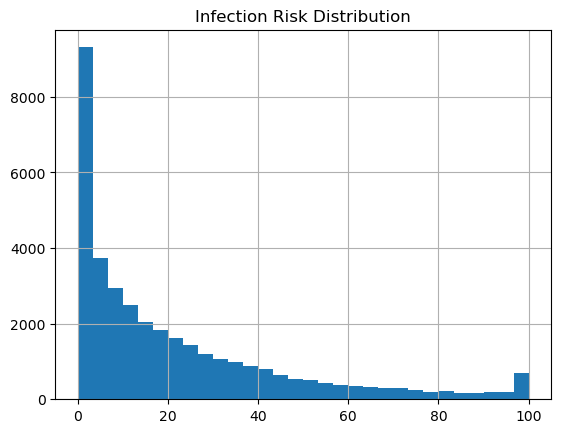

In [97]:
df['Infection_%'].hist(bins=30)
plt.title("Infection Risk Distribution")
plt.show()